GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


898/898 ━━━━━━━━━━━━━━━━━━━━ 544s 590ms/step - accuracy: 0.2379 - loss: 1.8337 - val_accuracy: 0.2555 - val_loss: 1.7983
Epoch 2/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 411s 454ms/step - accuracy: 0.2426 - loss: 1.8167 - val_accuracy: 0.2799 - val_loss: 1.7878
Epoch 3/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 405s 447ms/step - accuracy: 0.2410 - loss: 1.8120 - val_accuracy: 0.2522 - val_loss: 1.8082
Epoch 4/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 404s 447ms/step - accuracy: 0.2434 - loss: 1.8122 - val_accuracy: 0.2086 - val_loss: 1.8075
Epoch 5/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 411s 454ms/step - accuracy: 0.2492 - loss: 1.8028 - val_accuracy: 0.2873 - val_loss: 1.7860
Epoch 6/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 408s 451ms/step - accuracy: 0.2422 - loss: 1.8123 - val_accuracy: 0.2549 - val_loss: 1.7955
Epoch 7/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 405s 447ms/step - accuracy: 0.2541 - loss: 1.7999 - val_accuracy: 0.2899 - val_loss: 1.7594
Epoch 8/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 410s 453ms/step - accuracy: 0.2466 - loss: 1.80

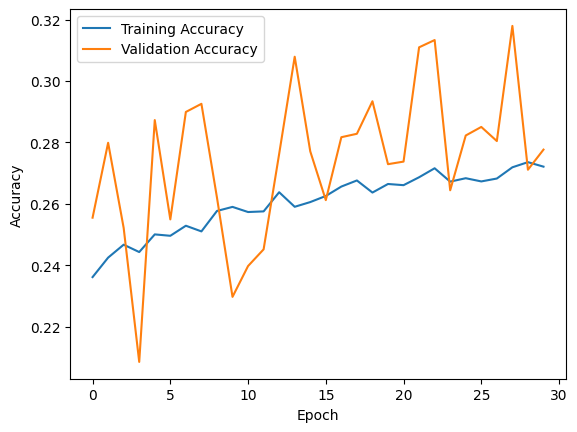

In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import time

# Check if GPU is available
if not tf.config.list_physical_devices('GPU'):
    print("No GPU available. Please select GPU from the Runtime menu -> Change runtime type -> Hardware accelerator.")
else:
    print("GPU available:", tf.config.list_physical_devices('GPU'))

# Set the image directory path
data_dir = '/kaggle/input/fer2013'

# Define data generators with data augmentation and normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Initialize data generators
train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'train'),
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(data_dir, 'test'),
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical'
)

# Define the ResNet50 model with transfer learning
base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(256, 256, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(7, activation='softmax')
])

# Compile the model
model.compile(optimizer=optimizers.Adam(),
              loss=losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

# Train the model
num_epochs = 30
start_time = time.time()

history = model.fit(train_generator,
                    epochs=num_epochs,
                    validation_data=test_generator)

# Evaluate the trained model
test_loss, test_acc = model.evaluate(test_generator)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import matplotlib.pyplot as plt
import time
import os

# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Define transforms for data preprocessing
transforms_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    
])

transforms_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Load the dataset
data_dir = '/kaggle/input/fer2013'
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transforms_train)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transforms_test)

# Define data loaders
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

# Define the model
model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(train_dataset.classes)) # Change output size based on dataset
model = model.to(device)

# Define loss function and optimizer (you can change these)
criterion = nn.CrossEntropyLoss()  # Change loss function if needed
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # Change optimizer and learning rate if needed

# Training the model
num_epochs = 30
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    print('[Epoch {}/{}] Loss: {:.4f} Acc: {:.4f}'.format(epoch + 1, num_epochs, epoch_loss, epoch_acc))

print('Training complete. Time taken: {:.2f} seconds'.format(time.time() - start_time))

# Evaluating the model
model.eval()
test_running_loss = 0.0
test_running_corrects = 0

for inputs, labels in test_dataloader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    loss = criterion(outputs, labels)

    test_running_loss += loss.item() * inputs.size(0)
    test_running_corrects += torch.sum(preds == labels.data)

test_loss = test_running_loss / len(test_dataset)
test_accuracy = test_running_corrects.double() / len(test_dataset)

print('Test Loss: {:.4f}'.format(test_loss))
print('Test Accuracy: {:.4f}'.format(test_accuracy))


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s] 


[Epoch 1/30] Loss: 1.2915 Acc: 0.5249
[Epoch 2/30] Loss: 1.0188 Acc: 0.6229
[Epoch 3/30] Loss: 0.9521 Acc: 0.6494
[Epoch 4/30] Loss: 0.8600 Acc: 0.6870
[Epoch 5/30] Loss: 0.7781 Acc: 0.7145
[Epoch 6/30] Loss: 0.7060 Acc: 0.7430
[Epoch 7/30] Loss: 0.6671 Acc: 0.7610
[Epoch 8/30] Loss: 0.5916 Acc: 0.7867
[Epoch 9/30] Loss: 0.5207 Acc: 0.8132
[Epoch 10/30] Loss: 0.4633 Acc: 0.8335
[Epoch 11/30] Loss: 0.4295 Acc: 0.8484
[Epoch 12/30] Loss: 0.3567 Acc: 0.8731
[Epoch 13/30] Loss: 0.3307 Acc: 0.8854
[Epoch 14/30] Loss: 0.2786 Acc: 0.9021
[Epoch 15/30] Loss: 0.2433 Acc: 0.9145
[Epoch 16/30] Loss: 0.2229 Acc: 0.9220
[Epoch 17/30] Loss: 0.1916 Acc: 0.9362
[Epoch 18/30] Loss: 0.1866 Acc: 0.9367
[Epoch 19/30] Loss: 0.1630 Acc: 0.9444
[Epoch 20/30] Loss: 0.1498 Acc: 0.9505
[Epoch 21/30] Loss: 0.1235 Acc: 0.9590
[Epoch 22/30] Loss: 0.1061 Acc: 0.9636
[Epoch 23/30] Loss: 0.1017 Acc: 0.9671
[Epoch 24/30] Loss: 0.0892 Acc: 0.9698
[Epoch 25/30] Loss: 0.0778 Acc: 0.9750
[Epoch 26/30] Loss: 0.0699 Acc: 0.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate the model on the test dataset
model.eval()
predictions = []
true_labels = []

for inputs, labels in test_dataloader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)

    predictions.extend(preds.cpu().numpy())
    true_labels.extend(labels.cpu().numpy())

# Calculate precision, recall, and F1 score
precision = precision_score(true_labels, predictions, average='macro')
recall = recall_score(true_labels, predictions, average='macro')
f1 = f1_score(true_labels, predictions, average='macro')

print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)


NameError: name 'model' is not defined

In [18]:
# Function to save the model
def save_model(model, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print("Model saved successfully at:", save_path)

# Define the path where you want to save the model
save_path = "/content/drive/MyDrive/ML methods and models/save"

# Save the model
save_model(model, save_path)


NameError: name 'model' is not defined

In [ ]:
from google.colab import files
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Upload an image file
uploaded = files.upload()
original_data_path = "/content/drive/MyDrive/ML methods and models"

# Process and display the uploaded image
for filename in uploaded.keys():
    img = Image.open(filename)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Uploaded Image')
    plt.show()

    # Preprocess the uploaded image
    img_processed = transforms.Resize((256, 256))(img)
    img_processed = transforms.ToTensor()(img_processed)
    img_processed = transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])(img_processed)
    img_processed = img_processed.unsqueeze(0)  # Add batch dimension

    # Move the image to the same device as the model
    img_processed = img_processed.to(device)

    # Make predictions
    model.eval()
    with torch.no_grad():
        outputs = model(img_processed)
        _, predicted = torch.max(outputs, 1)

    # Print the predicted class
    predicted_class = train_dataset.classes[predicted.item()]
    print("Predicted class:", predicted_class)

    # Getting a comparison image from train dataset
    predicted_class_folder = os.path.join(original_data_path, predicted_class)
    image_files = os.listdir(predicted_class_folder)
    first_image_path = os.path.join(predicted_class_folder, image_files[0])

    # Display the image
    img = Image.open(first_image_path)
    plt.imshow(img)
    plt.axis('off')  # Hide axis
    plt.title('Comparison image from training data')
    plt.show()



In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import matplotlib.pyplot as plt
import time
import os

# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Define transforms for data preprocessing
transforms_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

transforms_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Load the dataset
data_dir = '/kaggle/input/fer2013'
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transforms_train)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transforms_test)

# Define data loaders
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)  # Adjust num_workers as needed
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)  # Adjust num_workers as needed

# Define the model
model = models.resnet18(weights='imagenet1k')
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(train_dataset.classes)) # Change output size based on dataset
model = model.to(device)

# Define loss function and optimizer (you can change these)
criterion = nn.CrossEntropyLoss()  # Change loss function if needed
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # Change optimizer and learning rate if needed

# Training the model
num_epochs = 30
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    print('[Epoch {}/{}] Loss: {:.4f} Acc: {:.4f}'.format(epoch + 1, num_epochs, epoch_loss, epoch_acc))

print('Training complete. Time taken: {:.2f} seconds'.format(time.time() - start_time))

# Evaluating the model
model.eval()
test_running_loss = 0.0
test_running_corrects = 0

for inputs, labels in test_dataloader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    loss = criterion(outputs, labels)

    test_running_loss += loss.item() * inputs.size(0)
    test_running_corrects += torch.sum(preds == labels.data)

test_loss = test_running_loss / len(test_dataset)
test_accuracy = test_running_corrects.double() / len(test_dataset)

print('Test Loss: {:.4f}'.format(test_loss))
print('Test Accuracy: {:.4f}'.format(test_accuracy))


KeyError: 'imagenet1k'

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import matplotlib.pyplot as plt
import time
import os

# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Define transforms for data preprocessing
transforms_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

transforms_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Load the dataset (Update the path for Kaggle dataset)
data_dir = '/kaggle/input/fer2013'  # Ensure this is the correct path
train_path = os.path.join(data_dir, 'train')
test_path = os.path.join(data_dir, 'test')

# Ensure dataset folders exist
if not os.path.exists(train_path) or not os.path.exists(test_path):
    raise FileNotFoundError("Dataset folders not found. Check your Kaggle dataset path.")

train_dataset = datasets.ImageFolder(train_path, transform=transforms_train)
test_dataset = datasets.ImageFolder(test_path, transform=transforms_test)

# Define data loaders
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Define the model (Fixed KeyError issue)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(train_dataset.classes))  # Change output size based on dataset
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Training the model
num_epochs = 30
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    print('[Epoch {}/{}] Loss: {:.4f} Acc: {:.4f}'.format(epoch + 1, num_epochs, epoch_loss, epoch_acc))

print('Training complete. Time taken: {:.2f} seconds'.format(time.time() - start_time))

# Evaluating the model
model.eval()
test_running_loss = 0.0
test_running_corrects = 0

with torch.no_grad():  # No gradient calculation for evaluation
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        test_running_loss += loss.item() * inputs.size(0)
        test_running_corrects += torch.sum(preds == labels.data)

test_loss = test_running_loss / len(test_dataset)
test_accuracy = test_running_corrects.double() / len(test_dataset)

print('Test Loss: {:.4f}'.format(test_loss))
print('Test Accuracy: {:.4f}'.format(test_accuracy))


Using device: cuda:0


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s] 


[Epoch 1/30] Loss: 1.3014 Acc: 0.5187
[Epoch 2/30] Loss: 1.0138 Acc: 0.6262
[Epoch 3/30] Loss: 0.9195 Acc: 0.6597
[Epoch 4/30] Loss: 0.8280 Acc: 0.6951
[Epoch 5/30] Loss: 0.7641 Acc: 0.7221
[Epoch 6/30] Loss: 0.6912 Acc: 0.7482
[Epoch 7/30] Loss: 0.6464 Acc: 0.7651
[Epoch 8/30] Loss: 0.5693 Acc: 0.7912
[Epoch 9/30] Loss: 0.5477 Acc: 0.8040
[Epoch 10/30] Loss: 0.4459 Acc: 0.8377
[Epoch 11/30] Loss: 0.4021 Acc: 0.8572
[Epoch 12/30] Loss: 0.3735 Acc: 0.8674
[Epoch 13/30] Loss: 0.3139 Acc: 0.8893
[Epoch 14/30] Loss: 0.3092 Acc: 0.8925
[Epoch 15/30] Loss: 0.2332 Acc: 0.9194
[Epoch 16/30] Loss: 0.2306 Acc: 0.9207
[Epoch 17/30] Loss: 0.1800 Acc: 0.9398
[Epoch 18/30] Loss: 0.1498 Acc: 0.9494
[Epoch 19/30] Loss: 0.1406 Acc: 0.9537
[Epoch 20/30] Loss: 0.1276 Acc: 0.9572
[Epoch 21/30] Loss: 0.1148 Acc: 0.9619
[Epoch 22/30] Loss: 0.1002 Acc: 0.9674
[Epoch 23/30] Loss: 0.0939 Acc: 0.9675
[Epoch 24/30] Loss: 0.0847 Acc: 0.9720
[Epoch 25/30] Loss: 0.0672 Acc: 0.9783
[Epoch 26/30] Loss: 0.0652 Acc: 0.

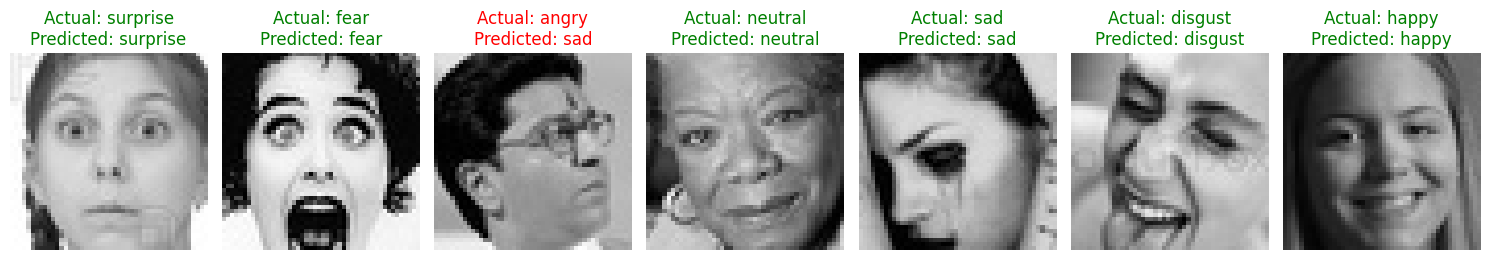

In [35]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from PIL import Image
from torchvision import transforms

def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))  # Convert tensor to numpy image
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    inp = std * inp + mean  # Unnormalize
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis("off")  # Hide axes for better visualization

# Load the trained model
model.eval()

# Define transform for images
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Folder containing test images
test_folder = "/kaggle/input/fer2013/test"  # Update with the actual path

# Get all class folders
class_folders = [os.path.join(test_folder, d) for d in os.listdir(test_folder) if os.path.isdir(os.path.join(test_folder, d))]

# Select random images from each class
selected_images = []
true_labels = []
for class_folder in class_folders:
    image_files = [f for f in os.listdir(class_folder) if f.endswith(('jpg', 'png', 'jpeg'))]
    if image_files:
        selected_image = random.choice(image_files)
        selected_images.append(os.path.join(class_folder, selected_image))
        true_labels.append(os.path.basename(class_folder))  # Get the actual class name

# Ensure images were selected
if not selected_images:
    raise FileNotFoundError("No images found in the specified folder structure.")

# Process and display images with predictions
fig, axes = plt.subplots(1, len(selected_images), figsize=(15, 5))  # Dynamic layout
if len(selected_images) == 1:
    axes = [axes]  # Ensure axes is iterable

for idx, image_path in enumerate(selected_images):
    image = Image.open(image_path).convert("RGB")  # Ensure RGB format
    image_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension

    # Get model prediction
    with torch.no_grad():
        output = model(image_tensor)
        _, pred = torch.max(output, 1)
    
    predicted_label = train_dataset.classes[pred.item()]
    true_label = true_labels[idx]  # Get actual label from folder name
    
    # Display image with prediction and actual label
    axes[idx].imshow(image)
    axes[idx].set_title(f'Actual: {true_label}\nPredicted: {predicted_label}', 
                        color='green' if true_label == predicted_label else 'red')
    axes[idx].axis("off")  # Hide axes

plt.tight_layout()
plt.show()